# Comparison: three ways of dealing with parametric vs. nonparametric

In [1]:
import duckdb
import geopandas as gpd
import icechunk
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr

from srm.bcsd_config import BCSDConfig
from srm.pipeline import BCSDPipeline

In [2]:
import logging

logging.basicConfig(level=logging.INFO, force=True)

# Also explicitly configure the srm logger
logger = logging.getLogger("srm")
logger.setLevel(logging.INFO)
if not logger.handlers:
    logger.addHandler(logging.StreamHandler())

## 1. Define Configuration

we'll configure a BCSD run for:
- GCM: CESM2-WACCM
- Variable: tas (temperature)
- Scenario: SSP245
- Region: South Africa
- Environment: qa (for testing)

In [3]:
# Define South Africa bounds
df = duckdb.sql(
    """
    install httpfs; load httpfs;
    install spatial; load spatial;
    SELECT name, ST_AsText(geom) as geometry
    FROM ST_Read('https://carbonplan-data.s3.us-west-2.amazonaws.com/countries-50m.json')
    WHERE NAME = 'South Africa'
    """
).df()
df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
south_africa_geom = gpd.GeoDataFrame(df, geometry="geometry")

# Set bounds with 2-degree buffer
lon_min, lat_min, lon_max, lat_max = south_africa_geom.total_bounds
bounds = [lat_min - 2, lat_max + 2, lon_min - 2, lon_max + 2]
bounds = [round(entry, 2) for entry in bounds]

print(f"South Africa subset bounds: {bounds}")

South Africa subset bounds: [np.float64(-48.96), np.float64(-20.15), np.float64(14.45), np.float64(39.89)]


# Run pipeline for nonparametric

In [4]:
# Create configuration
config = BCSDConfig(
    gcm="CESM2-WACCM",
    variable="tas",
    ensemble_member="r1i1p1f1",
    scenario="SSP245",
    train_period_start=1978,
    train_period_end=2014,
    predict_period_start=2015,
    predict_period_end=2100,
    subset_bounds=tuple(bounds),
    cache_dir="s3://carbonplan-scratch/srm/bcsd-cache",
    output_dir="s3://carbonplan-scratch/srm/outputs",
    environment="qa",  # Use 'qa' for testing
    version="v5.6_nonparametric",
    mapping_type="nonparametric",
    verbose=True,
    save_intermediate=True,
)

print(f"Run ID: {config.run_id}")
print(f"Config hash: {config.config_hash}")
print(f"Detrend data: {config.detrend_data}")

Run ID: CESM2-WACCM_tas_r1i1p1f1_SSP245_subset
Config hash: 3a1839139748
Detrend data: True


In [5]:
# Initialize pipeline
pipeline = BCSDPipeline(config)

# Run all three stages
print("Stage 1: Prepare observations (regrid ERA5 to GCM grid)")
obs_path_nonparametric = pipeline.prepare_observations(force=False)
print(f"✓ Observations cached at: {obs_path_nonparametric}\n")

print("Stage 2: Fit historical (debias and downscale historical period)")
hist_path_nonparametric = pipeline.fit_historical(force=False)
print(f"✓ Historical cached at: {hist_path_nonparametric}\n")

print("Stage 3: Transform scenario (debias and downscale future)")
scenario_path_nonparametric = pipeline.transform_scenario(force=False)
print(f"✓ Scenario output at: {scenario_path_nonparametric}")

Computing observation regridding for CESM2-WACCM/tas
INFO:srm.pipeline:Computing observation regridding for CESM2-WACCM/tas


Stage 1: Prepare observations (regrid ERA5 to GCM grid)
Loaded observations: 0.64 seconds
Regridded observations to coarse grid: 0.78 seconds


✓ Cached observations: s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_nonparametric/obs/CESM2-WACCM_tas_lat-48.96to-20.15_lon14.45to39.89_obs_regridded.icechunk
INFO:srm.pipeline:✓ Cached observations: s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_nonparametric/obs/CESM2-WACCM_tas_lat-48.96to-20.15_lon14.45to39.89_obs_regridded.icechunk
Computing historical downscaling for CESM2-WACCM/tas/r1i1p1f1
INFO:srm.pipeline:Computing historical downscaling for CESM2-WACCM/tas/r1i1p1f1


Saved to cache: 71.95 seconds
✓ Observations cached at: s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_nonparametric/obs/CESM2-WACCM_tas_lat-48.96to-20.15_lon14.45to39.89_obs_regridded.icechunk

Stage 2: Fit historical (debias and downscale historical period)
Loaded data: 0.98 seconds


INFO:ibicus:----- Running debiasing for variable: Daily mean near-surface air temperature -----
✓ Saved debiased historical: s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_nonparametric/historical/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_historical_debiased_coarse.icechunk
INFO:srm.pipeline:✓ Saved debiased historical: s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_nonparametric/historical/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_historical_debiased_coarse.icechunk


...

Saved coarse debiased scenario to cache: 1.28 seconds
Re-trended scenario: 0.01 seconds


✓ Saved debiased scenario: s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_nonparametric/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245_debiased_retrended_coarse.icechunk
INFO:srm.pipeline:✓ Saved debiased scenario: s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_nonparametric/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245_debiased_retrended_coarse.icechunk


Saved coarse debiased, retrended to cache: 1.23 seconds
Spatially disaggregated: 36.54 seconds


✓ Saved scenario output: s3://carbonplan-scratch/srm/outputs/qa/v5.6_nonparametric/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245.icechunk
INFO:srm.pipeline:✓ Saved scenario output: s3://carbonplan-scratch/srm/outputs/qa/v5.6_nonparametric/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245.icechunk


Saved output: 7.37 seconds
✓ Scenario output at: s3://carbonplan-scratch/srm/outputs/qa/v5.6_nonparametric/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245.icechunk


# Run pipeline for parametric

In [6]:
# Create configuration
config = BCSDConfig(
    gcm="CESM2-WACCM",
    variable="tas",
    ensemble_member="r1i1p1f1",
    scenario="SSP245",
    train_period_start=1978,
    train_period_end=2014,
    predict_period_start=2015,
    predict_period_end=2100,
    subset_bounds=tuple(bounds),
    cache_dir="s3://carbonplan-scratch/srm/bcsd-cache",
    output_dir="s3://carbonplan-scratch/srm/outputs",
    environment="qa",  # Use 'qa' for testing
    version="v5.6_parametric",
    mapping_type="parametric",
    verbose=True,
    save_intermediate=True,
)

print(f"Run ID: {config.run_id}")
print(f"Config hash: {config.config_hash}")
print(f"Detrend data: {config.detrend_data}")

Run ID: CESM2-WACCM_tas_r1i1p1f1_SSP245_subset
Config hash: 3a75acbedb6d
Detrend data: True


In [7]:
# Initialize pipeline
pipeline = BCSDPipeline(config)

# Run all three stages
print("Stage 1: Prepare observations (regrid ERA5 to GCM grid)")
obs_path_parametric = pipeline.prepare_observations(force=False)
print(f"✓ Observations cached at: {obs_path_parametric}\n")

print("Stage 2: Fit historical (debias and downscale historical period)")
hist_path_parametric = pipeline.fit_historical(force=False)
print(f"✓ Historical cached at: {hist_path_parametric}\n")

print("Stage 3: Transform scenario (debias and downscale future)")
scenario_path_parametric = pipeline.transform_scenario(force=False)
print(f"✓ Scenario output at: {scenario_path_parametric}")

Computing observation regridding for CESM2-WACCM/tas
INFO:srm.pipeline:Computing observation regridding for CESM2-WACCM/tas


Stage 1: Prepare observations (regrid ERA5 to GCM grid)
Loaded observations: 0.62 seconds
Regridded observations to coarse grid: 0.03 seconds


✓ Cached observations: s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_parametric/obs/CESM2-WACCM_tas_lat-48.96to-20.15_lon14.45to39.89_obs_regridded.icechunk
INFO:srm.pipeline:✓ Cached observations: s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_parametric/obs/CESM2-WACCM_tas_lat-48.96to-20.15_lon14.45to39.89_obs_regridded.icechunk
Computing historical downscaling for CESM2-WACCM/tas/r1i1p1f1
INFO:srm.pipeline:Computing historical downscaling for CESM2-WACCM/tas/r1i1p1f1


Saved to cache: 70.97 seconds
✓ Observations cached at: s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_parametric/obs/CESM2-WACCM_tas_lat-48.96to-20.15_lon14.45to39.89_obs_regridded.icechunk

Stage 2: Fit historical (debias and downscale historical period)
Loaded data: 0.96 seconds


INFO:ibicus:----- Running debiasing for variable: Daily mean near-surface air temperature -----
✓ Saved debiased historical: s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_parametric/historical/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_historical_debiased_coarse.icechunk
INFO:srm.pipeline:✓ Saved debiased historical: s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_parametric/historical/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_historical_debiased_coarse.icechunk


...

Saved coarse debiased scenario to cache: 1.18 seconds
Re-trended scenario: 0.01 seconds


✓ Saved debiased scenario: s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_parametric/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245_debiased_retrended_coarse.icechunk
INFO:srm.pipeline:✓ Saved debiased scenario: s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_parametric/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245_debiased_retrended_coarse.icechunk


Saved coarse debiased, retrended to cache: 1.23 seconds
Spatially disaggregated: 36.01 seconds


✓ Saved scenario output: s3://carbonplan-scratch/srm/outputs/qa/v5.6_parametric/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245.icechunk
INFO:srm.pipeline:✓ Saved scenario output: s3://carbonplan-scratch/srm/outputs/qa/v5.6_parametric/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245.icechunk


Saved output: 5.11 seconds
✓ Scenario output at: s3://carbonplan-scratch/srm/outputs/qa/v5.6_parametric/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245.icechunk


# Run pipeline for hybrid

In [8]:
# Create configuration
config = BCSDConfig(
    gcm="CESM2-WACCM",
    variable="tas",
    ensemble_member="r1i1p1f1",
    scenario="SSP245",
    train_period_start=1978,
    train_period_end=2014,
    predict_period_start=2015,
    predict_period_end=2100,
    subset_bounds=tuple(bounds),
    cache_dir="s3://carbonplan-scratch/srm/bcsd-cache",
    output_dir="s3://carbonplan-scratch/srm/outputs",
    environment="qa",  # Use 'qa' for testing
    version="v5.6_nonparametric_hybrid",
    mapping_type="nonparametric_hybrid",
    verbose=True,
    save_intermediate=True,
)

print(f"Run ID: {config.run_id}")
print(f"Config hash: {config.config_hash}")
print(f"Detrend data: {config.detrend_data}")

Run ID: CESM2-WACCM_tas_r1i1p1f1_SSP245_subset
Config hash: 5449d055dc96
Detrend data: True


In [9]:
# Initialize pipeline
pipeline = BCSDPipeline(config)

# Run all three stages
print("Stage 1: Prepare observations (regrid ERA5 to GCM grid)")
obs_path_hybrid = pipeline.prepare_observations(force=False)
print(f"✓ Observations cached at: {obs_path_hybrid}\n")

print("Stage 2: Fit historical (debias and downscale historical period)")
hist_path_hybrid = pipeline.fit_historical(force=False)
print(f"✓ Historical cached at: {hist_path_hybrid}\n")

print("Stage 3: Transform scenario (debias and downscale future)")
scenario_path_hybrid = pipeline.transform_scenario(force=False)
print(f"✓ Scenario output at: {scenario_path_hybrid}")

Computing observation regridding for CESM2-WACCM/tas
INFO:srm.pipeline:Computing observation regridding for CESM2-WACCM/tas


Stage 1: Prepare observations (regrid ERA5 to GCM grid)
Loaded observations: 0.65 seconds
Regridded observations to coarse grid: 0.02 seconds


✓ Cached observations: s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_nonparametric_hybrid/obs/CESM2-WACCM_tas_lat-48.96to-20.15_lon14.45to39.89_obs_regridded.icechunk
INFO:srm.pipeline:✓ Cached observations: s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_nonparametric_hybrid/obs/CESM2-WACCM_tas_lat-48.96to-20.15_lon14.45to39.89_obs_regridded.icechunk
Computing historical downscaling for CESM2-WACCM/tas/r1i1p1f1
INFO:srm.pipeline:Computing historical downscaling for CESM2-WACCM/tas/r1i1p1f1


Saved to cache: 69.69 seconds
✓ Observations cached at: s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_nonparametric_hybrid/obs/CESM2-WACCM_tas_lat-48.96to-20.15_lon14.45to39.89_obs_regridded.icechunk

Stage 2: Fit historical (debias and downscale historical period)
Loaded data: 1.02 seconds


INFO:ibicus:----- Running debiasing for variable: Daily mean near-surface air temperature -----
✓ Saved debiased historical: s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_nonparametric_hybrid/historical/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_historical_debiased_coarse.icechunk
INFO:srm.pipeline:✓ Saved debiased historical: s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_nonparametric_hybrid/historical/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_historical_debiased_coarse.icechunk


...

Saved coarse debiased scenario to cache: 1.18 seconds
Re-trended scenario: 0.01 seconds


✓ Saved debiased scenario: s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_nonparametric_hybrid/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245_debiased_retrended_coarse.icechunk
INFO:srm.pipeline:✓ Saved debiased scenario: s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_nonparametric_hybrid/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245_debiased_retrended_coarse.icechunk


Saved coarse debiased, retrended to cache: 1.21 seconds
Spatially disaggregated: 37.29 seconds


✓ Saved scenario output: s3://carbonplan-scratch/srm/outputs/qa/v5.6_nonparametric_hybrid/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245.icechunk
INFO:srm.pipeline:✓ Saved scenario output: s3://carbonplan-scratch/srm/outputs/qa/v5.6_nonparametric_hybrid/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245.icechunk


Saved output: 4.26 seconds
✓ Scenario output at: s3://carbonplan-scratch/srm/outputs/qa/v5.6_nonparametric_hybrid/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245.icechunk


# Compare data

In [10]:
# import icechunk
bucket = "carbonplan-scratch"
prefix_nonparametric = "srm/bcsd-cache/qa/6_nonparametric_hybrid/obs/CESM2-WACCM_tas_lat-48.96to-20.15_lon14.45to39.89_obs_regridded.icechunk"


def open_icechunk(path, prefix=prefix_nonparametric):
    bucket, prefix = path.replace("s3://", "").split("/", 1)
    storage = icechunk.s3_storage(bucket=bucket, prefix=prefix)
    repo = icechunk.Repository.open(storage)
    session = repo.readonly_session("main")

    ds = xr.open_dataset(session.store, engine="zarr", chunks={})
    return ds

In [11]:
bucket, prefix = obs_path_nonparametric.replace("s3://", "").split("/", 1)
bucket, prefix

('carbonplan-scratch',
 'srm/bcsd-cache/qa/v5.6_nonparametric/obs/CESM2-WACCM_tas_lat-48.96to-20.15_lon14.45to39.89_obs_regridded.icechunk')

In [12]:
# Load cached artifacts
obs_coarse_nonparametric = open_icechunk(obs_path_nonparametric, prefix=prefix_nonparametric)[
    config.variable
]
historical_downscaled_nonparametric = open_icechunk(
    hist_path_nonparametric, prefix=prefix_nonparametric
)[config.variable]
scenario_downscaled_nonparametric = open_icechunk(
    scenario_path_nonparametric, prefix=prefix_nonparametric
)[config.variable]

obs_coarse_parametric = open_icechunk(obs_path_parametric)[config.variable]
historical_downscaled_parametric = open_icechunk(hist_path_parametric)[config.variable]
scenario_downscaled_parametric = open_icechunk(scenario_path_parametric)[config.variable]

obs_coarse_hybrid = open_icechunk(obs_path_hybrid)[config.variable]
historical_downscaled_hybrid = open_icechunk(hist_path_hybrid)[config.variable]
scenario_downscaled_hybrid = open_icechunk(scenario_path_hybrid)[config.variable]

In [13]:
detrended_scenario_path = "s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.5_nonparametric/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245_detrended.icechunk"
detrended_scenario = open_icechunk(detrended_scenario_path)[config.variable]

In [16]:
debiased_scenario_coarse_nonparametric_path = "s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_nonparametric/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245_debiased_coarse.icechunk"
debiased_scenario_coarse_nonparametric = open_icechunk(debiased_scenario_coarse_nonparametric_path)[
    config.variable
]

debiased_scenario_coarse_hybrid_path = "s3://carbonplan-scratch/srm/bcsd-cache/qa/v5.6_nonparametric_hybrid/ssp245/CESM2-WACCM_tas_r1i1p1f1_lat-48.96to-20.15_lon14.45to39.89_ssp245_debiased_coarse.icechunk"
debiased_scenario_coarse_hybrid = open_icechunk(debiased_scenario_coarse_hybrid_path)[
    config.variable
]

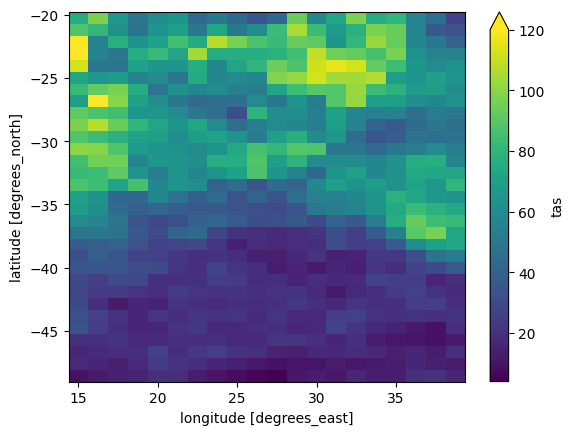

In [19]:
(debiased_scenario_coarse_hybrid != debiased_scenario_coarse_nonparametric).sum(dim="time").plot(
    vmax=120
)

## 3. Load Results from Cache

the pipeline automatically caches intermediate artifacts and final outputs. let's load them for visualization.

In [20]:
# Also load the raw GCM data for comparison
from srm.downscaling_utils import get_experiment, get_obs, subset_space

# Load fine-resolution observations
obs_fine = get_obs(var=config.variable)
obs_fine = subset_space(obs_fine, bounds)
obs_fine = obs_fine.sel(time=slice("1978", "2014"))

# Load coarse GCM data
model_hist_raw = get_experiment(gcm=config.gcm, scenario="Historical", var=config.variable)
if "ensemble_member" in model_hist_raw.dims:
    model_hist_raw = model_hist_raw.sel(ensemble_member=config.ensemble_member)
model_hist_raw = subset_space(model_hist_raw, bounds)
model_hist_raw = model_hist_raw.sel(time=slice("1978", "2014"))

model_scenario_raw = get_experiment(gcm=config.gcm, scenario=config.scenario, var=config.variable)
model_scenario_raw = model_scenario_raw.sel(ensemble_member=config.ensemble_member)
model_scenario_raw = subset_space(model_scenario_raw, bounds)
model_scenario_raw = model_scenario_raw.sel(time=slice("2015", "2100"))

print("Loaded raw GCM data for comparison")

Loaded raw GCM data for comparison


## 4. Visualize Results at Cape Town

extract time series at Cape Town and compare:
1. raw model output (coarse)
2. debiased model output (coarse)
3. debiased + downscaled output (fine resolution)

In [21]:
# Get Cape Town coordinates
cities = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_populated_places_simple.zip",
    columns=["name", "sov0name", "geometry"],
)
sa_cities = cities[cities["sov0name"] == "South Africa"]
cape_town_lon = float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.x.item())
cape_town_lat = float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.y.item())

print(f"Cape Town: ({cape_town_lat:.2f}°, {cape_town_lon:.2f}°)")

Cape Town: (-33.92°, 18.43°)


In [22]:
# Extract Cape Town data
obs_fine_ct = obs_fine.sel(lat=cape_town_lat, lon=cape_town_lon, method="nearest").compute()
model_hist_raw_ct = model_hist_raw.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()
model_scenario_raw_ct = model_scenario_raw.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()

obs_coarse_ct_parametric = obs_coarse_parametric.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()
historical_downscaled_ct_parametric = historical_downscaled_parametric.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()
scenario_downscaled_ct_parametric = scenario_downscaled_parametric.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()

obs_coarse_ct_nonparametric = obs_coarse_nonparametric.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()
historical_downscaled_ct_nonparametric = historical_downscaled_nonparametric.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()
scenario_downscaled_ct_nonparametric = scenario_downscaled_nonparametric.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()

obs_coarse_ct_hybrid = obs_coarse_hybrid.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()
historical_downscaled_ct_hybrid = historical_downscaled_hybrid.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()
scenario_downscaled_ct_hybrid = scenario_downscaled_hybrid.sel(
    lat=cape_town_lat, lon=cape_town_lon, method="nearest"
).compute()

print("✓ Extracted Cape Town time series")

✓ Extracted Cape Town time series


### Distribution Comparison: Raw → Debiased → Downscaled

this shows how BCSD transforms the model output:
- **Left**: Raw GCM output (biased, coarse)
- **Middle**: after bias correction (matches obs distribution, coarse)
- **Right**: after bias correction + spatial disaggregation (fine resolution)

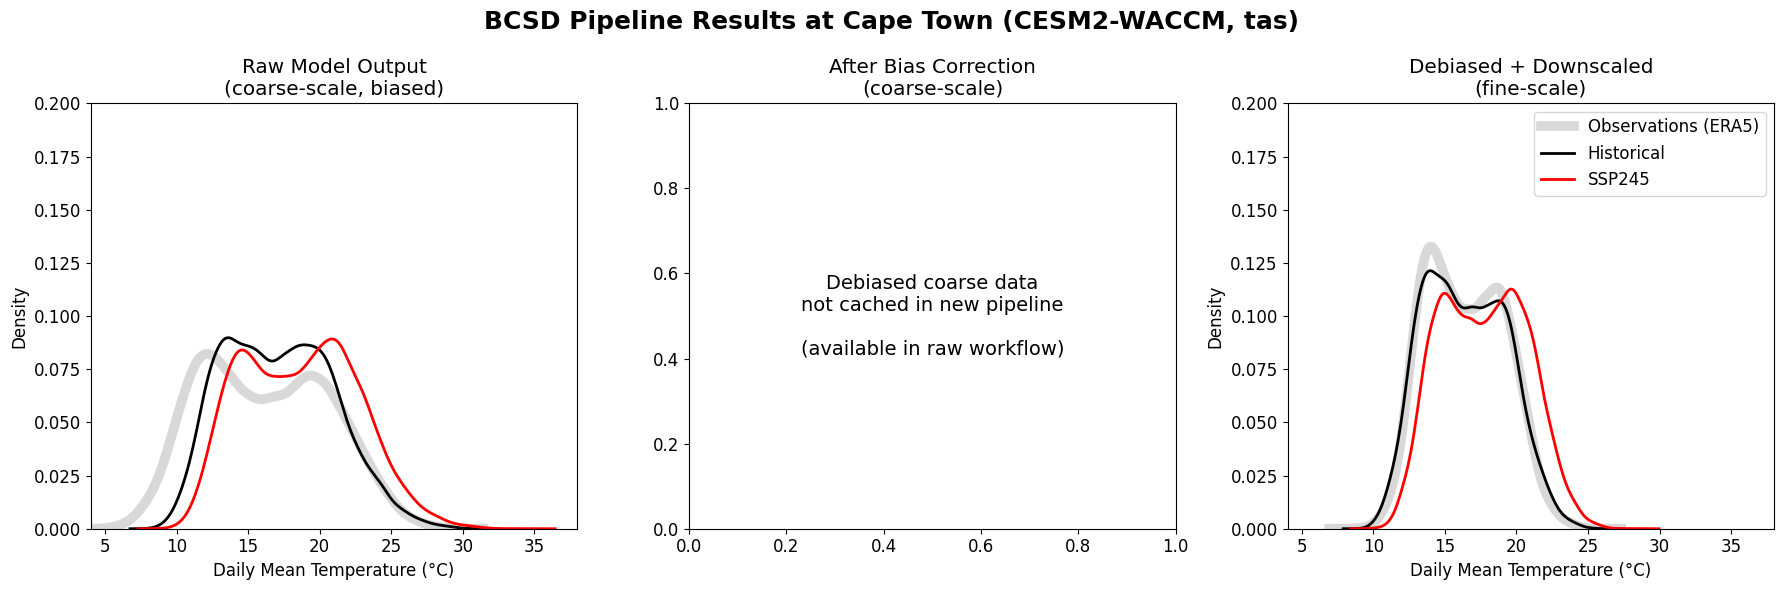

In [23]:
# Note: For the debiased coarse data, we need to compute it since pipeline doesn't cache it
# In production, we might want to cache the intermediate debiased-but-not-downscaled data

# Create figure
plt.rcParams["font.size"] = 12
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ["black", "red"]
labels = ["Historical", "SSP245"]


def format_subplot(ax, res="coarse"):
    """Add observation distribution to subplot"""
    if res == "coarse":
        sns.kdeplot(
            obs_coarse_ct_parametric.values - 273.15,
            label="Observations (ERA5)",
            color="gray",
            linewidth=7,
            alpha=0.3,
            linestyle="-",
            ax=ax,
        )
    elif res == "fine":
        sns.kdeplot(
            obs_fine_ct.values - 273.15,
            label="Observations (ERA5)",
            color="gray",
            linewidth=7,
            alpha=0.3,
            linestyle="-",
            ax=ax,
        )
    ax.set_ylim([0, 0.2])
    ax.set_xlim([4, 38])
    ax.set_xlabel("Daily Mean Temperature (°C)")


# Panel 1: Raw model output
ax = axes[0]
format_subplot(ax, res="coarse")
sns.kdeplot(
    model_hist_raw_ct.values - 273.15,
    label=labels[0],
    color=colors[0],
    linewidth=2,
    ax=ax,
)
sns.kdeplot(
    model_scenario_raw_ct.values - 273.15,
    label=labels[1],
    color=colors[1],
    linewidth=2,
    ax=ax,
)
ax.set_title("Raw Model Output\n(coarse-scale, biased)")

# Panel 2: Note - we don't have direct access to debiased-but-not-downscaled
# This would require modifying the pipeline to cache that intermediate step
# For now, we'll skip this panel or note it as unavailable
ax = axes[1]
ax.text(
    0.5,
    0.5,
    "Debiased coarse data\nnot cached in new pipeline\n\n(available in raw workflow)",
    ha="center",
    va="center",
    transform=ax.transAxes,
    fontsize=14,
)
ax.set_title("After Bias Correction\n(coarse-scale)")

# Panel 3: Downscaled output
ax = axes[2]
format_subplot(ax, res="fine")
sns.kdeplot(
    historical_downscaled_ct_parametric.values - 273.15,
    label=labels[0],
    color=colors[0],
    linewidth=2,
    ax=ax,
)
sns.kdeplot(
    scenario_downscaled_ct_parametric.values - 273.15,
    label=labels[1],
    color=colors[1],
    linewidth=2,
    ax=ax,
)
ax.set_title("Debiased + Downscaled\n(fine-scale)")

plt.suptitle(
    f"BCSD Pipeline Results at Cape Town ({config.gcm}, {config.variable})",
    fontsize=18,
    fontweight="bold",
)

axes[2].legend(fontsize=12)
plt.tight_layout()
plt.show()

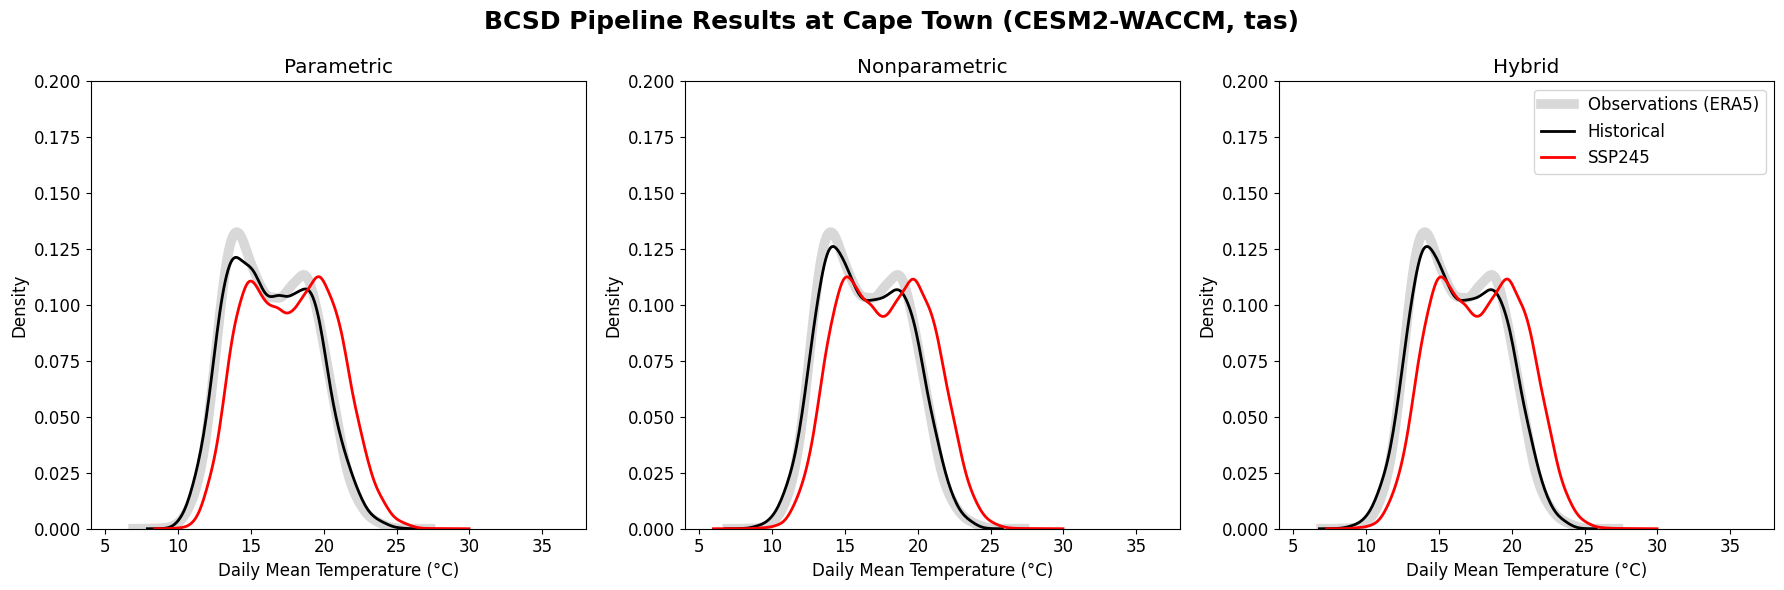

In [24]:
# Note: For the debiased coarse data, we need to compute it since pipeline doesn't cache it
# In production, we might want to cache the intermediate debiased-but-not-downscaled data

# Create figure
plt.rcParams["font.size"] = 12
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ["black", "red"]
labels = ["Historical", "SSP245"]


def format_subplot(ax, res="coarse"):
    """Add observation distribution to subplot"""
    if res == "coarse":
        sns.kdeplot(
            obs_coarse_ct_parametric.values - 273.15,
            label="Observations (ERA5)",
            color="gray",
            linewidth=7,
            alpha=0.3,
            linestyle="-",
            ax=ax,
        )
    elif res == "fine":
        sns.kdeplot(
            obs_fine_ct.values - 273.15,
            label="Observations (ERA5)",
            color="gray",
            linewidth=7,
            alpha=0.3,
            linestyle="-",
            ax=ax,
        )
    ax.set_ylim([0, 0.2])
    ax.set_xlim([4, 38])
    ax.set_xlabel("Daily Mean Temperature (°C)")


# Panel 1: Raw model output
ax = axes[0]
format_subplot(ax, res="fine")
sns.kdeplot(
    historical_downscaled_ct_parametric.values - 273.15,
    label=labels[0],
    color=colors[0],
    linewidth=2,
    ax=ax,
)
sns.kdeplot(
    scenario_downscaled_ct_parametric.values - 273.15,
    label=labels[1],
    color=colors[1],
    linewidth=2,
    ax=ax,
)
ax.set_title("Parametric")

ax = axes[1]
format_subplot(ax, res="fine")
sns.kdeplot(
    historical_downscaled_ct_nonparametric.values - 273.15,
    label=labels[0],
    color=colors[0],
    linewidth=2,
    ax=ax,
)
sns.kdeplot(
    scenario_downscaled_ct_nonparametric.values - 273.15,
    label=labels[1],
    color=colors[1],
    linewidth=2,
    ax=ax,
)
ax.set_title("Nonparametric")

ax = axes[2]
format_subplot(ax, res="fine")
sns.kdeplot(
    historical_downscaled_ct_hybrid.values - 273.15,
    label=labels[0],
    color=colors[0],
    linewidth=2,
    ax=ax,
)
sns.kdeplot(
    scenario_downscaled_ct_hybrid.values - 273.15,
    label=labels[1],
    color=colors[1],
    linewidth=2,
    ax=ax,
)
ax.set_title("Hybrid")

plt.suptitle(
    f"BCSD Pipeline Results at Cape Town ({config.gcm}, {config.variable})",
    fontsize=18,
    fontweight="bold",
)

axes[2].legend(fontsize=12)
plt.tight_layout()
plt.show()

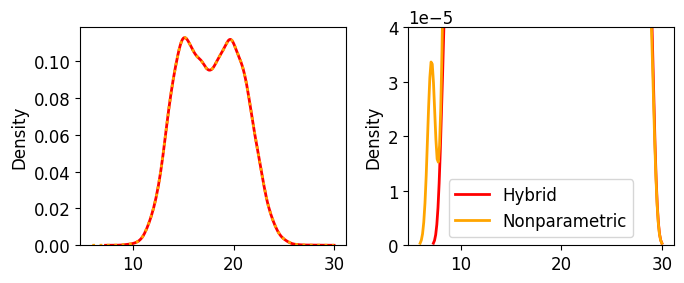

In [43]:
plt.figure(figsize=(7, 3))
plt.subplot(1, 2, 1)
sns.kdeplot(
    scenario_downscaled_ct_hybrid.values - 273.15,
    label=labels[1],
    color=colors[1],
    linewidth=2,
)
sns.kdeplot(
    scenario_downscaled_ct_nonparametric.values - 273.15,
    label=labels[1],
    color="orange",
    linestyle=":",
    linewidth=2,
)
plt.subplot(1, 2, 2)
sns.kdeplot(
    scenario_downscaled_ct_hybrid.values - 273.15,
    label="Hybrid",
    color=colors[1],
    linewidth=2,
)
sns.kdeplot(
    scenario_downscaled_ct_nonparametric.values - 273.15,
    label="Nonparametric",
    color="orange",
    linestyle="-",
    linewidth=2,
)
plt.legend()
plt.ylim([0, 0.00004])
plt.tight_layout()

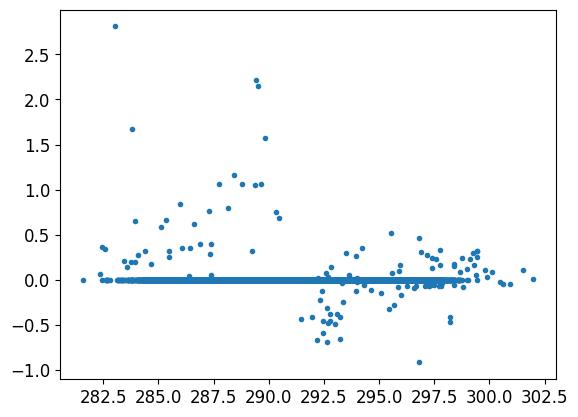

In [25]:
plt.plot(
    scenario_downscaled_ct_hybrid,
    scenario_downscaled_ct_hybrid - scenario_downscaled_ct_nonparametric,
    ".",
)

In [26]:
import numpy as np

print(np.nanmax(obs_coarse_hybrid - obs_coarse_nonparametric))
print(np.nanmin(obs_coarse_hybrid - obs_coarse_nonparametric))

print(np.nanmax(obs_coarse_hybrid - obs_coarse_parametric))
print(np.nanmin(obs_coarse_hybrid - obs_coarse_parametric))

print(np.nanmax(historical_downscaled_nonparametric - historical_downscaled_nonparametric))
print(np.nanmin(historical_downscaled_nonparametric - historical_downscaled_nonparametric))

0.0
0.0
0.0
0.0
0.0
0.0


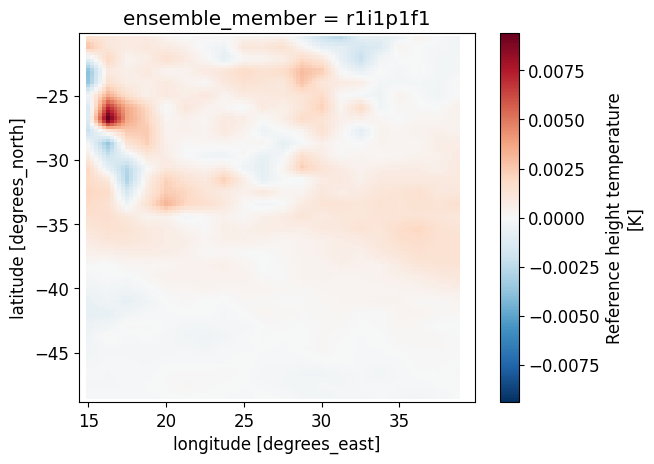

In [27]:
(scenario_downscaled_hybrid - scenario_downscaled_nonparametric).mean(dim="time").plot()

In [46]:
hot_extreme_delta_map = (scenario_downscaled_hybrid).quantile(0.99, dim="time") - (
    scenario_downscaled_nonparametric
).quantile(0.99, dim="time")

In [49]:
cold_extreme_delta_map = (scenario_downscaled_hybrid).quantile(0.01, dim="time") - (
    scenario_downscaled_nonparametric
).quantile(0.01, dim="time")

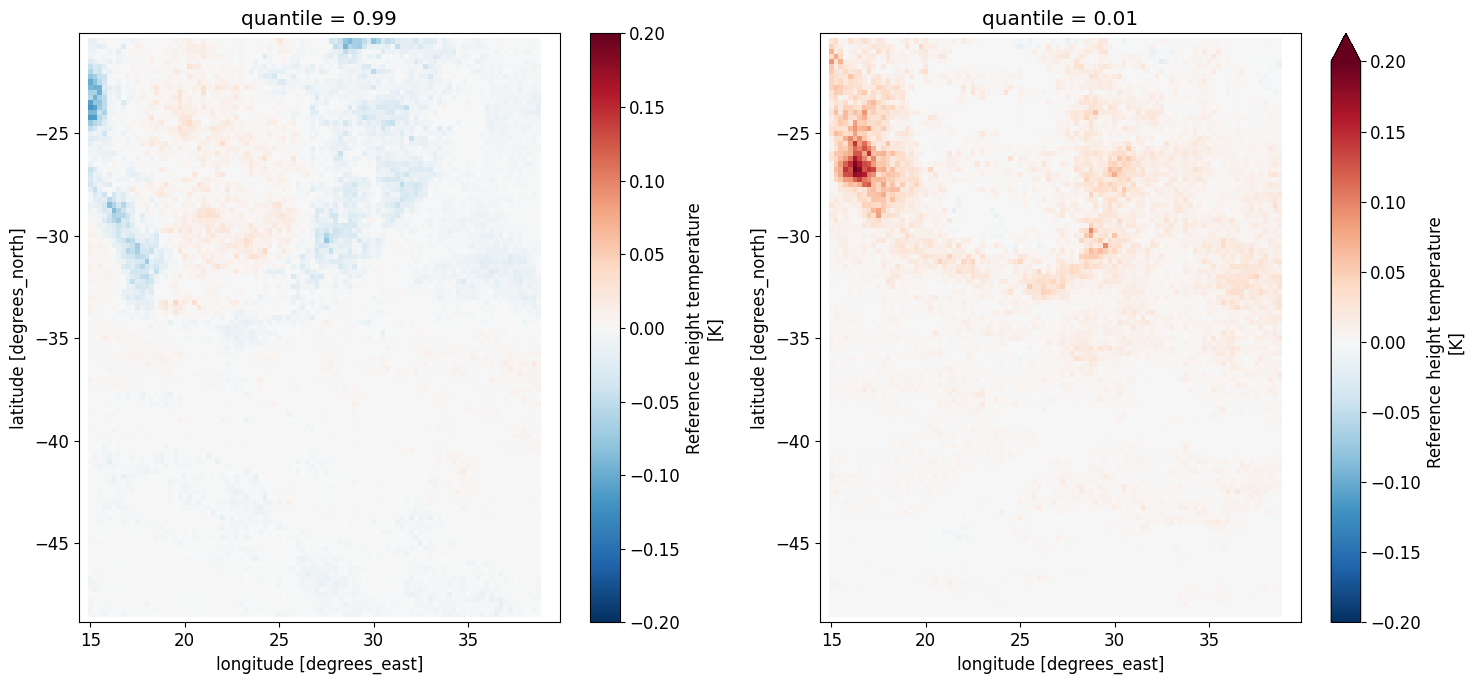

In [52]:
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
hot_extreme_delta_map.plot(vmax=0.2)
plt.subplot(1, 2, 2)
cold_extreme_delta_map.plot(vmax=0.2)
plt.tight_layout()

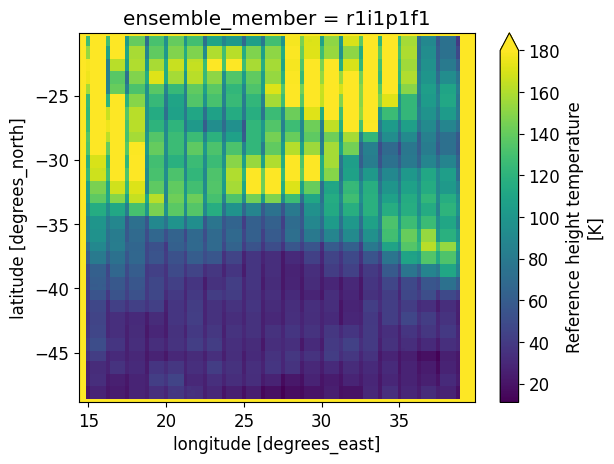

In [30]:
(scenario_downscaled_hybrid != scenario_downscaled_nonparametric).sum(dim="time").plot(vmax=180)